1. Handle missing values
    Basic Data analysis
        Remove data
        Imputation- time series (moving average)
2. Data integrity/outlier
3. Data transformation (Do not replace the original columns)

Continious data
    standardscore=(X-mu)/sigma
    min-max scaler=(X-Xmin)/(Xmax-Xmin) ->[0,1]

Discrete data
1 hot encouding or scale encoding

4. New Col. 
    Remove
    Update

5. How about x 10,000 larger
     What database you will use?


Feature Engineering

In [232]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [233]:
# ulitary code for be a rockstar 
from scipy import stats
def plot_missing_by_batches(df, sample_size=5000, cols_per_plot=40, random_state=42):
    """
    Hace heatmaps de NA usando:
    - una muestra de filas (sample_size)
    - columnas en batches de tamaño cols_per_plot
    """
    # 1) sample de filas (igual idea que antes)
    n_rows = len(df)
    sample_size = min(sample_size, n_rows)
    sample = df.sample(sample_size, random_state=random_state)

    n_cols = sample.shape[1]
    col_names = sample.columns.tolist()

    print(f"Sample usado para plots: {sample_size} filas, {n_cols} columnas")

    # 2) recorrer columnas en bloques
    for start in range(0, n_cols, cols_per_plot):
        end = min(start + cols_per_plot, n_cols)
        batch_cols = col_names[start:end]

        plt.figure(figsize=(14, 6))
        sns.heatmap(sample[batch_cols].isnull(), cbar=False)
        plt.title(f"Missing values heatmap (columnas {start}–{end-1})")
        plt.xlabel(f"Columnas {start}–{end-1}")
        plt.ylabel("Filas (sample)")
        plt.show()


def resumetable(df):
    print(f"Dataset Shape: {df.shape}")
    summary = pd.DataFrame(df.dtypes,columns=['dtypes'])
    summary = summary.reset_index()
    summary['Name'] = summary['index']
    summary = summary[['Name','dtypes']]
    summary['Missing'] = df.isnull().sum().values  
    summary['percentage missing'] = df.isnull().sum().values/df.shape[0] * 100    
    summary['Uniques'] = df.nunique().values
    summary['First Value'] = df.loc[0].values
    summary['Second Value'] = df.loc[1].values
    summary['Third Value'] = df.loc[2].values

    for name in summary['Name'].value_counts().index:
        summary.loc[summary['Name'] == name, 'Entropy'] = round(stats.entropy(df[name].value_counts(normalize=True), base=2),2) 

    return summary

In [ ]:

# Load the dataset
file_path = "loan.csv"
# Read the CSV file
df = pd.read_csv(file_path)




### 1. Handling Missing Values

First, I summarized all columns using a custom `resumetable` function.  
For each feature I computed:

- number of missing values  
- percentage missing  
- number of unique values  
- entropy (approximate information content)

Then I assigned an *action* rule:

- **`drop_constant`**: columns with only 1 unique value → no information (e.g., `policy_code`).
- **`high_card_text`**: very high-cardinality text (`emp_title`) → excluded from this project, because one-hot encoding would explode dimensionality.
- **`impute_num_simple`**: numerical columns with low missingness (≤5%) → imputed with median.
- **`impute_cat_mode`**: categorical columns with low missingness (≤5%) → imputed with the most frequent category.
- **`impute_with_flag`**: columns with 5–40% missing values → imputed plus an extra flag column indicating that the value was originally missing.
- **`consider_drop_or_flag`**: columns with more than 40% missing values (e.g., `mths_since_last_delinq`, `next_pymnt_d`) → dropped from the modeling dataset because they provide limited information relative to their missingness.

This approach is “reasonable” because it:
- preserves almost all observations,
- uses robust statistics (median/mode),
- and avoids introducing strong bias by dropping many rows.


In [ ]:
df_loan = df.copy()
varx_sample=1500000

summary = resumetable(df_loan[:varx_sample])

display(summary[:60].sort_values('Missing', ascending=False))
display(summary[60:112].sort_values('Missing', ascending=False))
display(summary[112:].sort_values('Missing', ascending=False))

print("to delete")
cols_over_60 = (
    summary[summary["percentage missing"] > 60]
    .sort_values("percentage missing", ascending=False)
)

display(cols_over_60)

Dataset Shape: (1500000, 145)


,Name,dtypes,Missing,percentage missing,Uniques,First Value,Second Value,Third Value,Entropy
0,id,float64,1500000,100.000000,0,NaN,NaN,NaN,0.00
18,url,float64,1500000,100.000000,0,NaN,NaN,NaN,0.00
1,member_id,float64,1500000,100.000000,0,NaN,NaN,NaN,0.00
19,desc,object,1499932,99.995467,51,NaN,NaN,NaN,4.98
55,verification_status_joint,object,1414788,94.319200,3,NaN,NaN,NaN,1.46
54,dti_joint,float64,1409818,93.987867,4009,NaN,NaN,NaN,11.61
53,annual_inc_joint,float64,1409814,93.987600,13858,NaN,NaN,NaN,9.59
29,mths_since_last_record,float64,1252881,83.525400,128,45.0,75.0,NaN,6.65
50,mths_since_last_major_derog,float64,1095931,73.062067,179,NaN,NaN,NaN,6.38
28,mths_since_last_delinq,float64,758292,50.552800,169,NaN,71.0,NaN,6.30


,Name,dtypes,Missing,percentage missing,Uniques,First Value,Second Value,Third Value,Entropy
111,revol_bal_joint,float64,1422496,94.833067,47858,NaN,NaN,NaN,15.35
86,mths_since_recent_bc_dlq,float64,1146234,76.415600,174,NaN,NaN,NaN,6.40
88,mths_since_recent_revol_delinq,float64,996079,66.405267,176,NaN,NaN,NaN,6.34
65,il_util,float64,561237,37.415800,269,69.0,88.0,72.0,6.53
63,mths_since_rcnt_il,float64,434649,28.976600,395,2.0,3.0,14.0,5.73
69,all_util,float64,399944,26.662933,181,28.0,57.0,35.0,6.41
73,inq_last_12m,float64,399785,26.652333,46,2.0,2.0,0.0,2.77
72,total_cu_tl,float64,399785,26.652333,60,11.0,15.0,5.0,2.31
62,open_il_24m,float64,399784,26.652267,31,2.0,3.0,2.0,2.40
71,inq_fi,float64,399784,26.652267,33,1.0,2.0,1.0,2.02


,Name,dtypes,Missing,percentage missing,Uniques,First Value,Second Value,Third Value,Entropy
134,orig_projected_additional_accrued_interest,float64,1493393,99.559533,5866,NaN,NaN,NaN,12.46
133,hardship_loan_status,object,1491646,99.443067,5,NaN,NaN,NaN,1.73
129,hardship_end_date,object,1491646,99.443067,27,NaN,NaN,NaN,4.19
132,hardship_dpd,float64,1491646,99.443067,34,NaN,NaN,NaN,4.42
127,hardship_amount,float64,1491646,99.443067,7233,NaN,NaN,NaN,12.74
126,deferral_term,float64,1491646,99.443067,1,NaN,NaN,NaN,0.00
125,hardship_status,object,1491646,99.443067,3,NaN,NaN,NaN,1.06
124,hardship_reason,object,1491646,99.443067,9,NaN,NaN,NaN,2.70
123,hardship_type,object,1491646,99.443067,1,NaN,NaN,NaN,0.00
128,hardship_start_date,object,1491646,99.443067,26,NaN,NaN,NaN,4.04


to delete


,Name,dtypes,Missing,percentage missing,Uniques,First Value,Second Value,Third Value,Entropy
0,id,float64,1500000,100.000000,0,NaN,NaN,NaN,0.00
1,member_id,float64,1500000,100.000000,0,NaN,NaN,NaN,0.00
18,url,float64,1500000,100.000000,0,NaN,NaN,NaN,0.00
19,desc,object,1499932,99.995467,51,NaN,NaN,NaN,4.98
134,orig_projected_additional_accrued_interest,float64,1493393,99.559533,5866,NaN,NaN,NaN,12.46
131,hardship_length,float64,1491646,99.443067,1,NaN,NaN,NaN,0.00
132,hardship_dpd,float64,1491646,99.443067,34,NaN,NaN,NaN,4.42
125,hardship_status,object,1491646,99.443067,3,NaN,NaN,NaN,1.06
126,deferral_term,float64,1491646,99.443067,1,NaN,NaN,NaN,0.00
127,hardship_amount,float64,1491646,99.443067,7233,NaN,NaN,NaN,12.74


During import, we encountered a DtypeWarning indicating mixed types. To ensure consistent typing and avoid data corruption, we loaded the file with low_memory=False and reviewed the affected columns.


In [ ]:
display(df_loan.shape)
display(cols_over_60.shape)

# columnas a eliminar (lista)
list_to_delete = cols_over_60["Name"].tolist()

# FIX: comparar cada columna, no la lista completa
# si alguna columna está en df_loan, entonces procede
if any(col in df_loan.columns for col in list_to_delete):
    df_loan = df_loan.drop(columns=list_to_delete, errors='ignore')

display(df_loan.shape)
display(cols_over_60.shape)

print("to delete round 2")
summary = resumetable(df_loan[:varx_sample])
cols_over_60 = (
    summary[summary["percentage missing"] > 60]
    .sort_values("percentage missing", ascending=False)
)

display(cols_over_60)





(2260668, 145)

(42, 9)

(2260668, 103)

(42, 9)

to delete round 2
Dataset Shape: (1500000, 103)


,Name,dtypes,Missing,percentage missing,Uniques,First Value,Second Value,Third Value,Entropy


In [ ]:
display(summary[:60].sort_values('Uniques', ascending=False))
display(summary[60:].sort_values('Uniques', ascending=False))


,Name,dtypes,Missing,percentage missing,Uniques,First Value,Second Value,Third Value,Entropy
33,total_pymnt,float64,0,0.000000,1037976,167.02,1507.11,353.89,19.38
34,total_pymnt_inv,float64,0,0.000000,919703,167.02,1507.11,353.89,19.19
36,total_rec_int,float64,0,0.000000,499293,53.04,894.86,141.1,18.21
41,last_pymnt_amnt,float64,0,0.000000,475764,84.92,777.23,180.69,16.42
49,tot_cur_bal,float64,0,0.000000,430965,16901.0,321915.0,110299.0,18.11
35,total_rec_prncp,float64,0,0.000000,368518,113.98,612.25,212.79,14.01
8,emp_title,object,118052,7.870133,309249,Chef,Postmaster,Administrative,14.03
32,out_prncp_inv,float64,0,0.000000,293923,2386.02,29387.75,4787.21,9.28
31,out_prncp,float64,0,0.000000,283287,2386.02,29387.75,4787.21,9.23
55,total_bal_il,float64,399784,26.652267,150587,12560.0,87153.0,7150.0,15.11


,Name,dtypes,Missing,percentage missing,Uniques,First Value,Second Value,Third Value,Entropy
96,tot_hi_cred_lim,float64,0,0.000000,465499,60124.0,372872.0,136927.0,17.86
97,total_bal_ex_mort,float64,0,0.000000,194237,16901.0,99468.0,11749.0,16.87
99,total_il_high_credit_limit,float64,0,0.000000,178135,18124.0,94072.0,10000.0,14.89
67,bc_open_to_buy,float64,16943,1.129533,84287,34360.0,13761.0,13800.0,14.70
66,avg_cur_bal,float64,42,0.002800,80920,1878.0,24763.0,18383.0,15.01
61,total_rev_hi_lim,float64,0,0.000000,22623,42000.0,50800.0,24100.0,9.99
98,total_bc_limit,float64,0,0.000000,10275,36500.0,15000.0,13800.0,9.35
70,delinq_amnt,float64,0,0.000000,2052,0.0,0.0,0.0,0.07
68,bc_util,float64,17690,1.179333,1434,5.9,8.3,0.0,9.92
72,mo_sin_old_rev_tl_op,float64,0,0.000000,769,212.0,378.0,92.0,8.51


Sample usado para plots: 5000 filas, 103 columnas


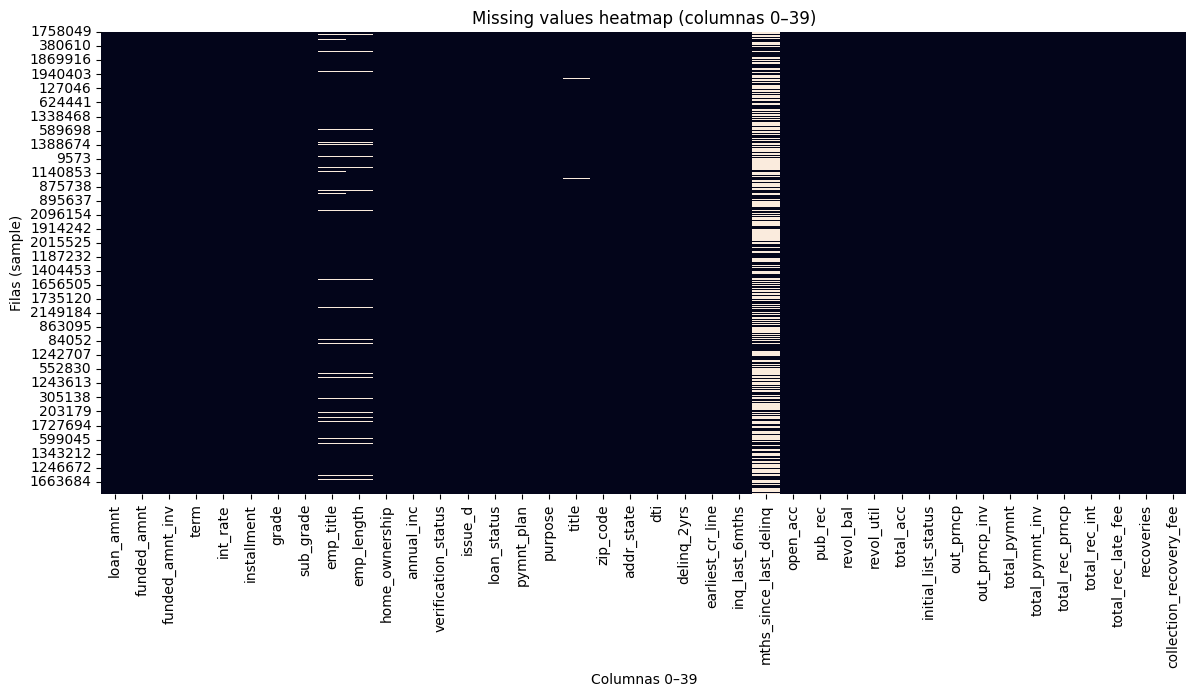

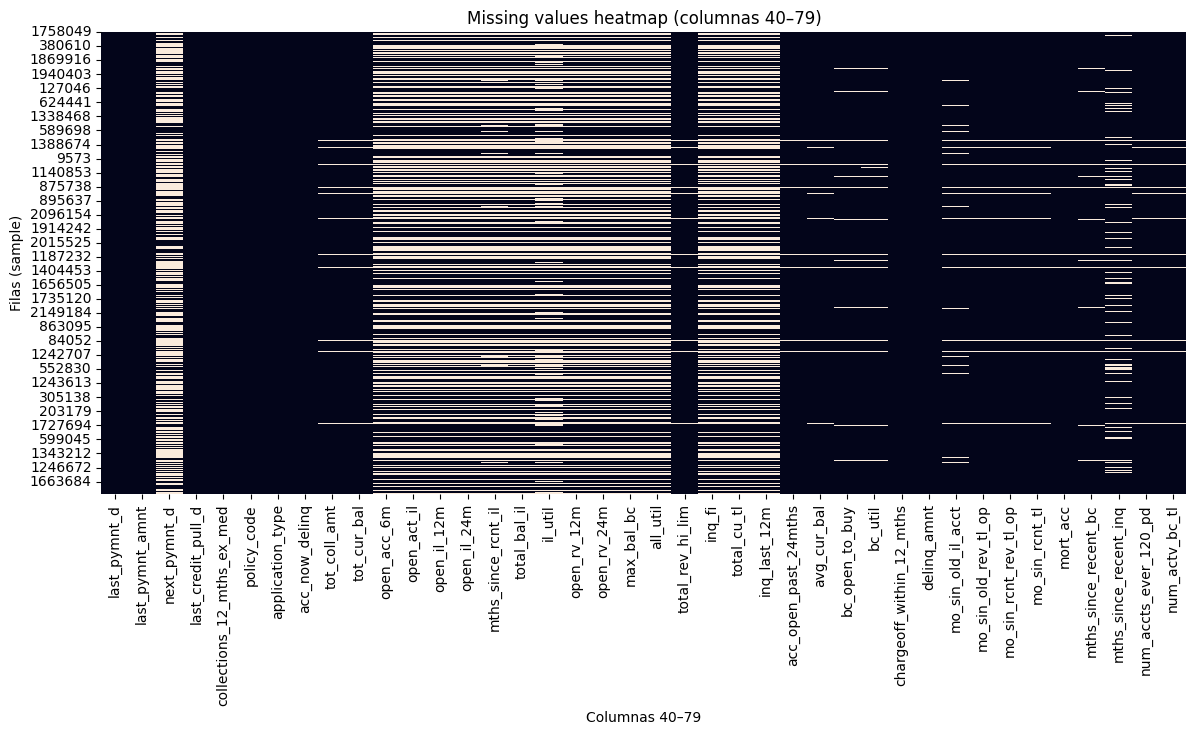

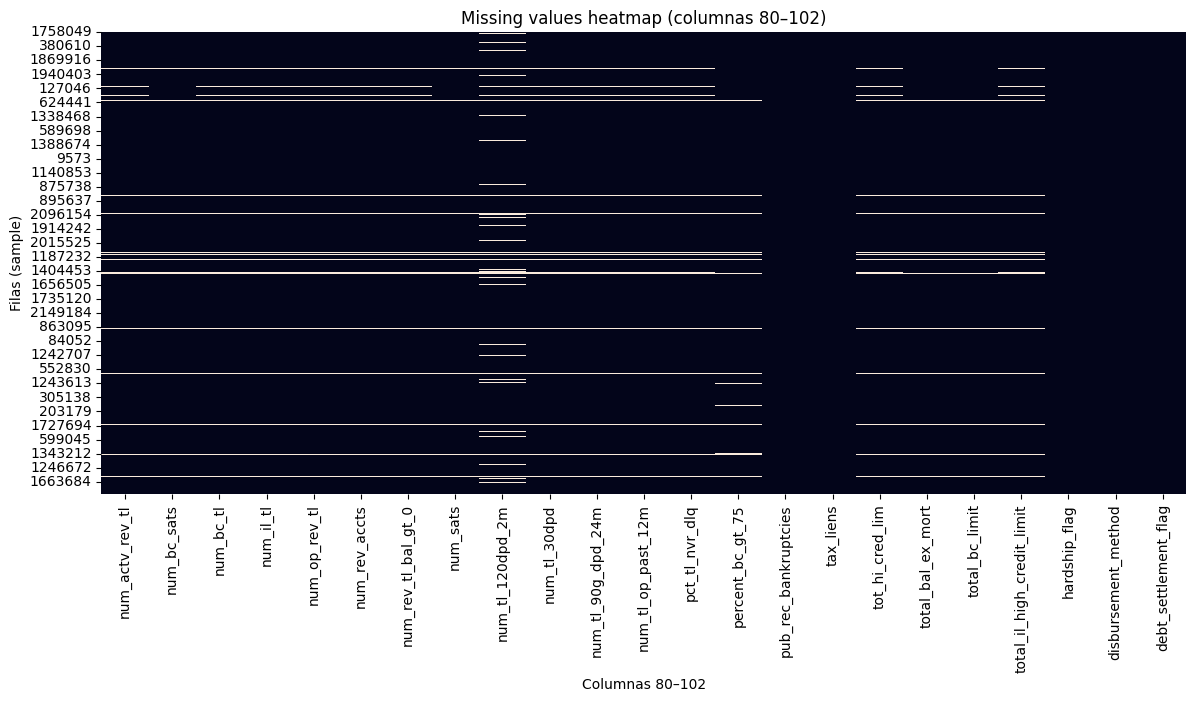

In [ ]:
plot_missing_by_batches(df_loan, sample_size=5000, cols_per_plot=40)

In [ ]:
import pandas as pd
from IPython.display import display

# Parameters
MAX_VALUES = 100      # global cap: max number of unique values shown per column
CHUNK_SIZE = 13       # max number of columns per display

# 1) Use summary ONLY to select low-cardinality columns
cols_low_card = summary.loc[summary["Uniques"] < 100, ["Name", "Uniques"]].copy()

# 2) Recompute uniques *from df_loan* to avoid mismatch
cols_low_card["True_Uniques"] = cols_low_card["Name"].apply(
    lambda c: df_loan[c].nunique(dropna=True)
)

# 3) Sort by the true unique count (DESC)
cols_low_card = cols_low_card.sort_values("True_Uniques", ascending=False)

# Show reference table (summary uniques vs true uniques)
display(cols_low_card)

col_names_ordered = cols_low_card["Name"].tolist()

# 4) Build blocks of up to CHUNK_SIZE columns each
for start in range(0, len(col_names_ordered), CHUNK_SIZE):
    chunk_cols = col_names_ordered[start:start + CHUNK_SIZE]

    # First pass: compute uniques per column and store
    chunk_info = {}

    for col in chunk_cols:
        # All uniques (drop NaN)
        uniques = df_loan[col].dropna().unique()

        # Sort values if possible
        try:
            uniques = sorted(uniques)
        except TypeError:
            pass

        # True unique count from df_loan
        unique_count = df_loan[col].nunique(dropna=True)

        # Limit displayed uniques globally to MAX_VALUES
        uniques_display = uniques[:MAX_VALUES]

        chunk_info[col] = {
            "unique_count": unique_count,
            "uniques_display": uniques_display,
        }

    # Max number of values we will display in THIS chunk
    chunk_max_values = max(len(info["uniques_display"]) for info in chunk_info.values())

    # 5) Build matrix for this chunk
    data = {}
    for col in chunk_cols:
        unique_count = chunk_info[col]["unique_count"]
        uniques_display = list(chunk_info[col]["uniques_display"])

        # First row = unique count
        col_values = [unique_count] + uniques_display

        # Pad to 1 + chunk_max_values
        needed_len = 1 + chunk_max_values
        if len(col_values) < needed_len:
            col_values.extend([pd.NA] * (needed_len - len(col_values)))

        data[col] = col_values

    # Index labels adapt to this chunk
    index_labels = ["Unique_Count"] + [
        f"value_{i}" for i in range(1, chunk_max_values + 1)
    ]
    df_block = pd.DataFrame(data, index=index_labels)

    # 6) Show the chunk
    display(
        df_block.style.set_caption(
            f"Columns {start+1}–{start+len(chunk_cols)} "
            f"(sorted by True_Uniques DESC, max {chunk_max_values} values in this chunk)"
        )
    )


,Name,Uniques,True_Uniques
17,title,28,63154
43,last_credit_pull_d,52,140
13,issue_d,41,139
40,last_pymnt_d,50,135
42,next_pymnt_d,7,105
25,open_acc,87,91
87,num_sats,86,91
84,num_op_rev_tl,79,81
82,num_bc_tl,76,76
63,total_cu_tl,60,62


,title,last_credit_pull_d,issue_d,last_pymnt_d,next_pymnt_d,open_acc,num_sats,num_op_rev_tl,num_bc_tl,total_cu_tl,num_bc_sats,num_actv_rev_tl,acc_open_past_24mths
Unique_Count,63154,140,139,135,105,91,91,81,76,62,60,57,57
value_1,credit_card,Apr-2009,Apr-2008,Apr-2008,Apr-2008,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
value_2,debt_consolidation,Apr-2010,Apr-2009,Apr-2009,Apr-2009,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
value_3,house,Apr-2011,Apr-2010,Apr-2010,Apr-2010,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
value_4,other,Apr-2012,Apr-2011,Apr-2011,Apr-2011,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
value_5,small_business,Apr-2013,Apr-2012,Apr-2012,Apr-2012,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
value_6,debt consolidation,Apr-2014,Apr-2013,Apr-2013,Apr-2013,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
value_7,HITEK EQUIPMENT,Apr-2015,Apr-2014,Apr-2014,Apr-2014,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000
value_8,A lending hand,Apr-2016,Apr-2015,Apr-2015,Apr-2015,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000
value_9,Consolidation,Apr-2017,Apr-2016,Apr-2016,Apr-2019,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000


,open_act_il,addr_state,open_rv_24m,num_rev_tl_bal_gt_0,inq_last_12m,mort_acc,num_accts_ever_120_pd,pub_rec,num_actv_bc_tl,tax_liens,delinq_2yrs,sub_grade,num_tl_90g_dpd_24m
Unique_Count,54.000000,51,50,50,48,47,44,43,42,42,37,35,34
value_1,0.000000,AK,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,A1,0.000000
value_2,1.000000,AL,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,A2,1.000000
value_3,2.000000,AR,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,A3,2.000000
value_4,3.000000,AZ,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,A4,3.000000
value_5,4.000000,CA,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,A5,4.000000
value_6,5.000000,CO,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,B1,5.000000
value_7,6.000000,CT,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,B2,6.000000
value_8,7.000000,DC,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,B3,7.000000
value_9,8.000000,DE,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,B4,8.000000


,num_tl_op_past_12m,inq_fi,open_il_24m,open_rv_12m,inq_last_6mths,mths_since_recent_inq,open_il_12m,open_acc_6m,collections_12_mths_ex_med,purpose,pub_rec_bankruptcies,chargeoff_within_12_mths,emp_length
Unique_Count,33.000000,33.000000,31,29,28,26,19,19,16,14,12,11,11
value_1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,car,0.000000,0.000000,1 year
value_2,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,credit_card,1.000000,1.000000,10+ years
value_3,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,debt_consolidation,2.000000,2.000000,2 years
value_4,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,educational,3.000000,3.000000,3 years
value_5,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,home_improvement,4.000000,4.000000,4 years
value_6,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,house,5.000000,5.000000,5 years
value_7,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,major_purchase,6.000000,6.000000,6 years
value_8,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,medical,7.000000,7.000000,7 years
value_9,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,moving,8.000000,8.000000,8 years


,acc_now_delinq,loan_status,grade,num_tl_120dpd_2m,home_ownership,num_tl_30dpd,verification_status,hardship_flag,disbursement_method,term,application_type,initial_list_status,pymnt_plan
Unique_Count,9.000000,9,7,7,6,5,3,2,2,2,2,2,2
value_1,0.000000,Charged Off,A,0.000000,ANY,0.000000,Not Verified,N,Cash,36 months,Individual,f,n
value_2,1.000000,Current,B,1.000000,MORTGAGE,1.000000,Source Verified,Y,DirectPay,60 months,Joint App,w,y
value_3,2.000000,Default,C,2.000000,NONE,2.000000,Verified,,,,,,
value_4,3.000000,Does not meet the credit policy. Status:Charged Off,D,3.000000,OTHER,3.000000,,,,,,,
value_5,4.000000,Does not meet the credit policy. Status:Fully Paid,E,4.000000,OWN,4.000000,,,,,,,
value_6,5.000000,Fully Paid,F,6.000000,RENT,,,,,,,,
value_7,6.000000,In Grace Period,G,7.000000,,,,,,,,,
value_8,7.000000,Late (16-30 days),,,,,,,,,,,
value_9,14.000000,Late (31-120 days),,,,,,,,,,,


,debt_settlement_flag,policy_code
Unique_Count,2,1
value_1,N,1
value_2,Y,


Recommendation: FLATTEN emp_title (309k uniques)

Why flatten?
Because job titles have infinite variation:

“Software Engineer”

“software engineer”

“SWE”

“Sr Software Developer”

“Dev Engineer I”
→ ALL mean the same job category.

Final bucket categories (recommended):

Bucket	Examples
Management	manager, director, supervisor, vp
Professional	engineer, developer, analyst, accountant
Medical	nurse, rn, doctor, medical assistant
Education	teacher, professor
Sales	sales, representative, consultant
Service	driver, cleaner, cashier
Military	army, navy, marine
Retired / Unemployed	retired, unemployed
Other	everything else




Recommendation: FLATTEN title (63k uniques)

title contains loan purpose in free text, e.g.:

"Debt consolidation"

"Debt Consolidation"

"debt_consolidation"

"CC Consolidation"

"Credit card payoff"

"Card Payoff"

"Consolidation Loan"

"Wedding Loan"

"Medical Loan"

"Auto"


Recommendation: Reduce zip_code from 942 → 50 (states)

Every zip begins with first 3 digits, but you already have addr_state.

:/ Drop zip_code because it duplicates geography and makes 942 categories.


Reduce dates (issue_d, last_pymnt_d, last_credit_pull_d)

Instead of encoding 140+ unique date strings:

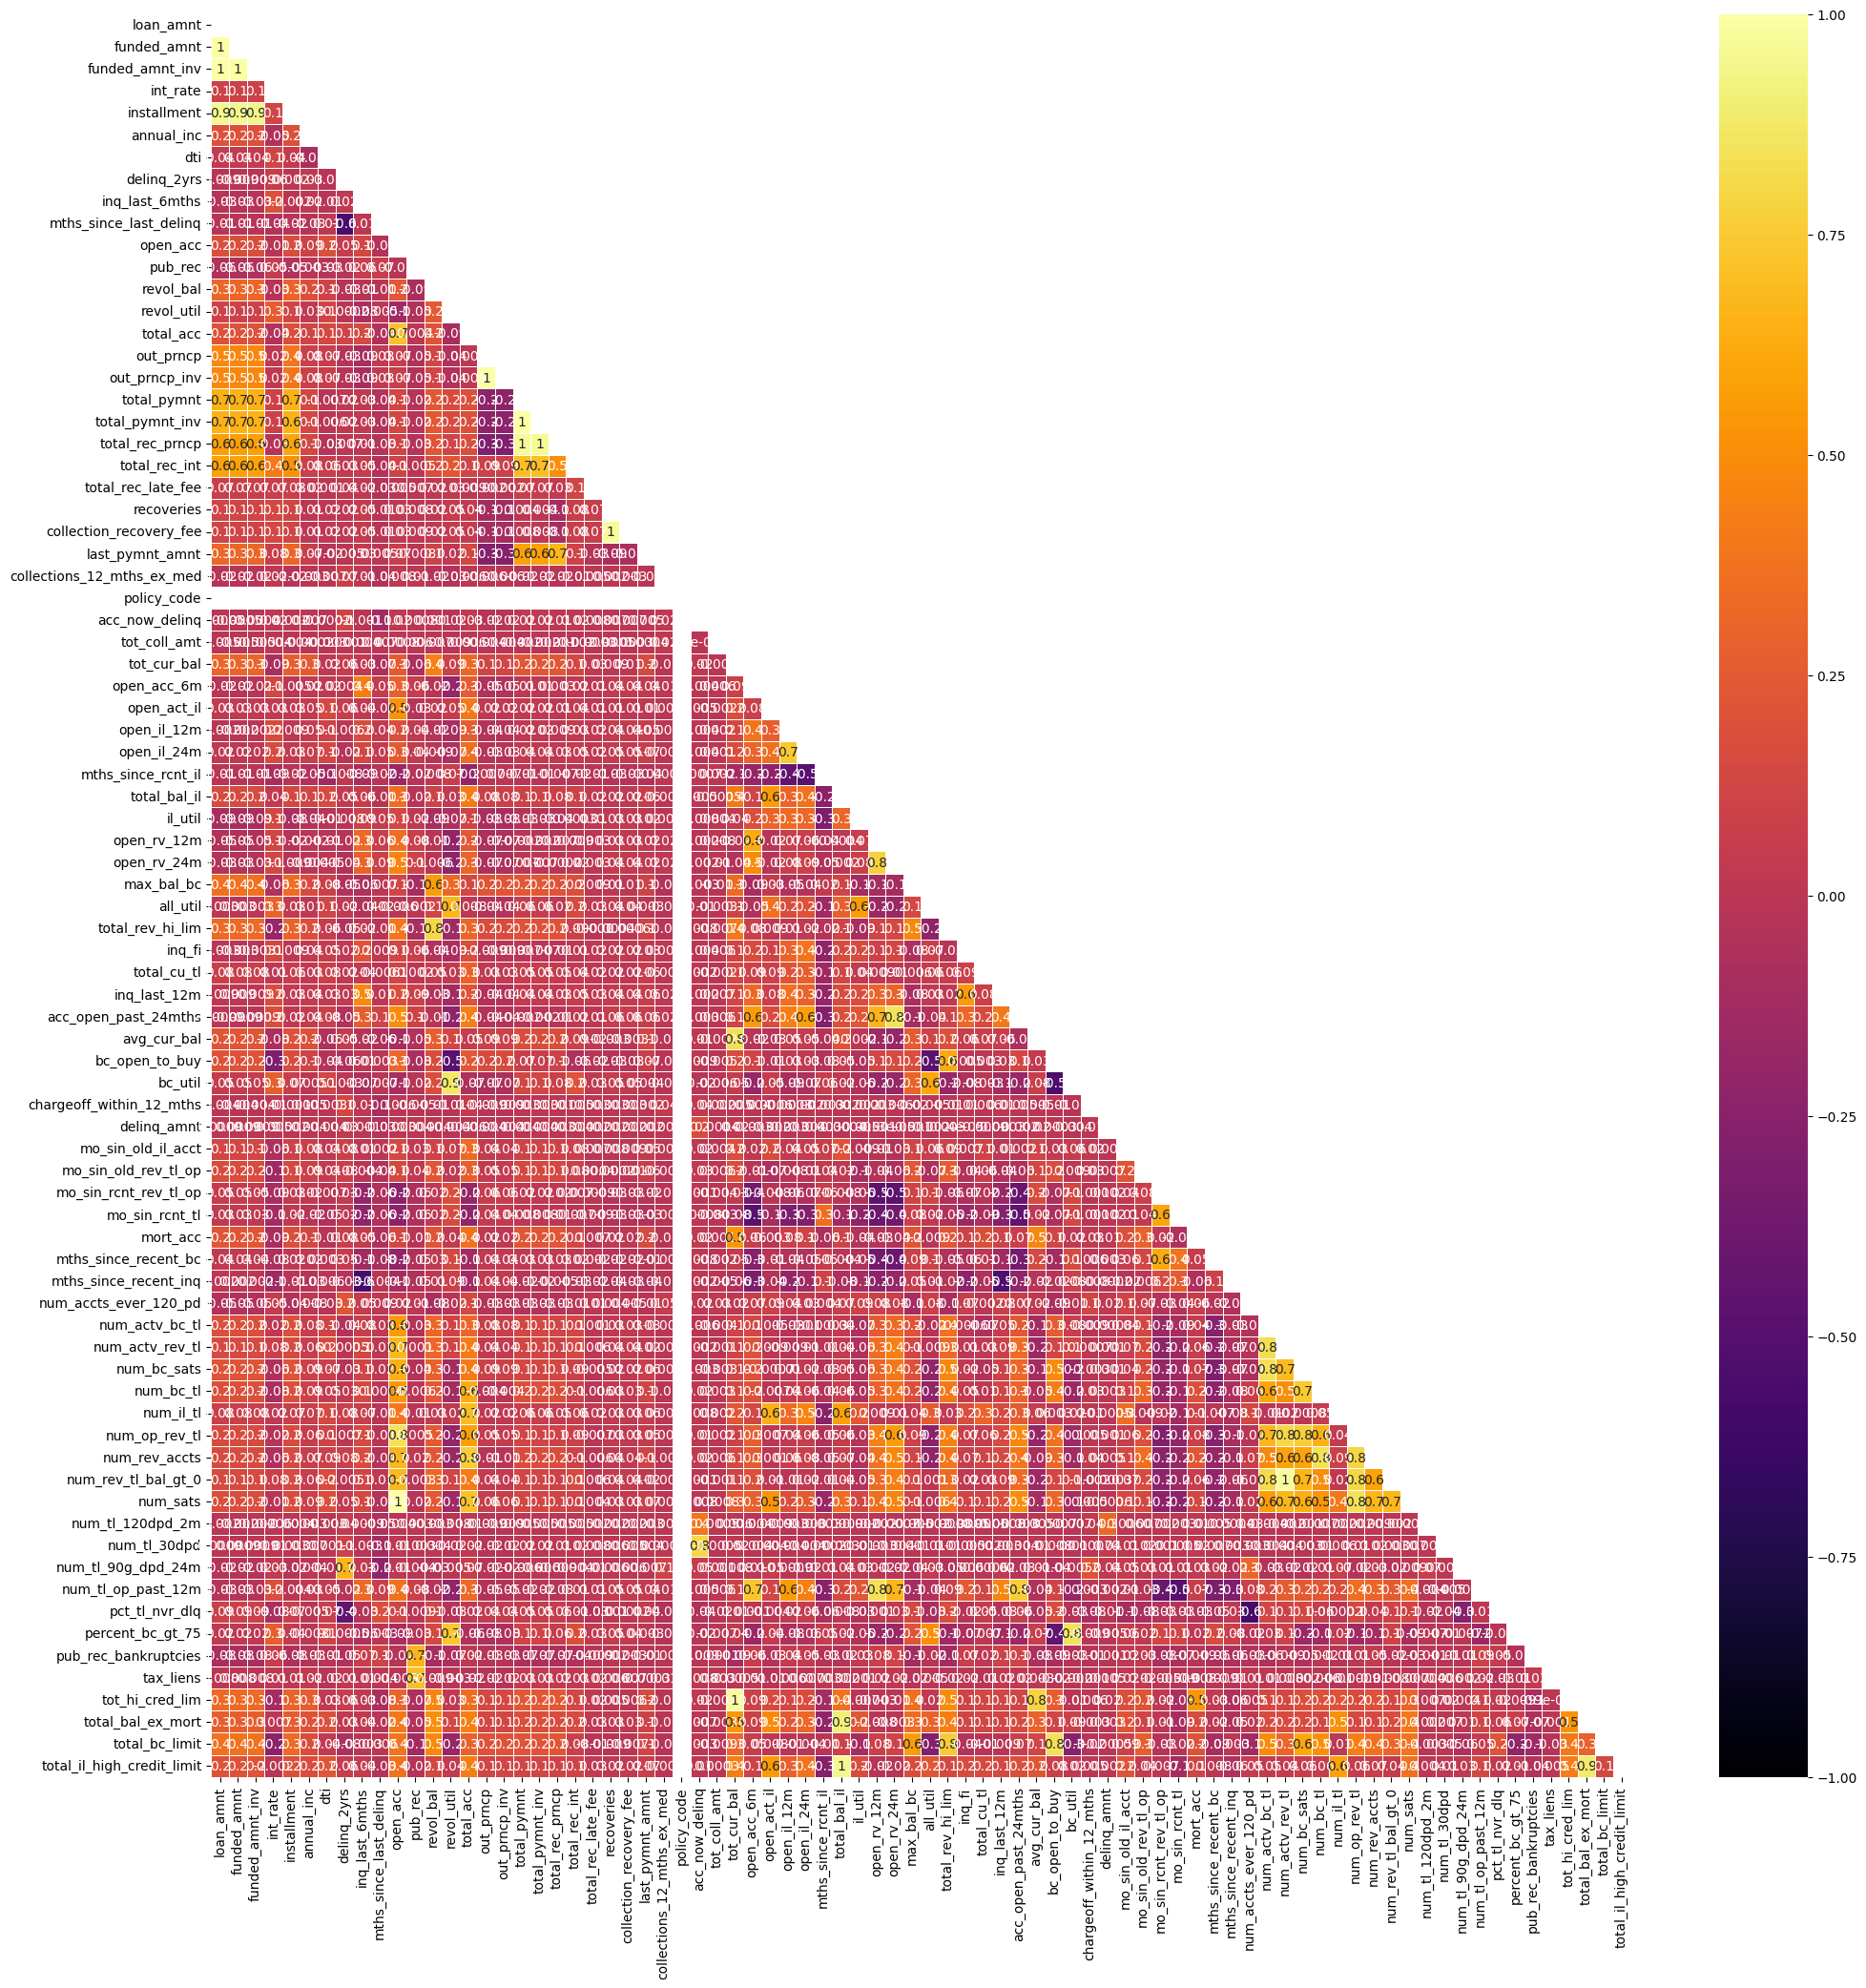

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Keep only numeric columns
df_num = df_loan.select_dtypes(include=[np.number])

# 2) Correlation matrix
corr = df_num.corr()   # by default numeric_only=True in recent pandas

# 3) Mask for upper triangle
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# 4) Plot heatmap
plt.figure(figsize=(24, 24))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap="inferno",
    vmin=-1,
    vmax=1,
    fmt=".1g",
    edgecolor="w",
    linewidths=0.6,
)
plt.show()


,loan_amnt,funded_amnt,funded_amnt_inv,installment,delinq_2yrs,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,recoveries,collection_recovery_fee,last_pymnt_amnt,acc_now_delinq,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,total_bal_il,open_rv_12m,open_rv_24m,all_util,total_rev_hi_lim,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mths_since_recent_bc,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
loan_amnt,1.000000,0.999755,0.999038,0.945627,-0.009277,0.182229,-0.058772,0.316715,0.099078,0.199570,0.471154,0.471168,0.651127,0.651193,0.578036,0.582108,0.120986,0.115894,0.317832,-0.000528,0.310189,-0.021955,0.033973,-0.001549,0.021711,0.150454,-0.045738,-0.034904,0.002576,0.328389,-0.000919,0.226125,0.205407,0.048369,0.052601,0.028277,0.036518,0.191162,0.149099,0.212375,0.192299,0.081454,0.161767,0.162594,0.148482,0.180023,0.000877,-0.023500,-0.026761,0.020816,-0.083562,0.007553,0.334985,0.276268,0.371526,0.208446
funded_amnt,0.999755,1.000000,0.999341,0.945969,-0.009173,0.182392,-0.058636,0.316643,0.099132,0.199483,0.471585,0.471599,0.651012,0.651133,0.577948,0.581957,0.120972,0.115941,0.317826,-0.000494,0.310189,-0.021953,0.033974,-0.001548,0.021712,0.150455,-0.045738,-0.034903,0.002575,0.328390,-0.000918,0.226126,0.205412,0.048364,0.052602,0.028278,0.036517,0.191162,0.149099,0.212375,0.192298,0.081454,0.161767,0.162593,0.148482,0.180024,0.000877,-0.023501,-0.026761,0.020814,-0.083447,0.007625,0.334985,0.276268,0.371530,0.208445
funded_amnt_inv,0.999038,0.999341,1.000000,0.945119,-0.009029,0.182601,-0.058288,0.316024,0.099087,0.199413,0.472290,0.472307,0.650037,0.651318,0.576995,0.581405,0.120624,0.115536,0.317617,-0.000441,0.310212,-0.021985,0.033965,-0.001559,0.021699,0.150450,-0.045775,-0.034950,0.002557,0.328408,-0.000945,0.226149,0.205467,0.048305,0.052623,0.028294,0.036537,0.191137,0.149062,0.212363,0.192264,0.081448,0.161746,0.162560,0.148446,0.180007,0.000865,-0.023518,-0.026786,0.020766,-0.083253,0.007773,0.335012,0.276270,0.371562,0.208450
installment,0.945627,0.945969,0.945119,1.000000,0.002053,0.171444,-0.047032,0.302815,0.120952,0.178342,0.387934,0.387920,0.650012,0.649965,0.597191,0.518753,0.118892,0.114126,0.306588,0.002121,0.277447,-0.004789,0.028767,0.009096,0.028660,0.138651,-0.021766,-0.008919,0.028323,0.297642,0.017574,0.198237,0.167829,0.074079,0.034007,0.015658,0.018537,0.193858,0.156028,0.204546,0.182787,0.065173,0.157855,0.153630,0.155154,0.168788,0.002944,-0.017056,-0.004151,0.044043,-0.075076,0.014309,0.299004,0.258431,0.334982,0.191123
delinq_2yrs,-0.009277,-0.009173,-0.009029,0.002053,1.000000,0.048956,-0.021810,-0.026779,-0.000200,0.118554,-0.029406,-0.029413,0.015669,0.015799,0.006973,0.031833,0.016317,0.016713,-0.005439,0.116076,0.056476,0.004136,0.056012,-0.005548,-0.019594,0.045564,-0.017840,-0.042546,0.024122,-0.048013,-0.050336,0.045286,-0.060352,0.002890,0.025842,0.017608,0.052741,-0.037681,-0.000495,-0.031124,0.034412,0.083474,0.007487,0.078806,-0.004672,0.045287,0.097881,0.656949,-0.022142,-0.000506,-0.049313,0.011384,0.056641,0.028158,-0.078074,0.056574
open_acc,0.182229,0.182392,0.182601,0.171444,0.048956,1.000000,-0.014849,0.237097,-0.134632,0.717911,0.067401,0.067397,0.128729,0.129084,0.116650,0.105302,0.032836,0.033405,0.066574,0.016877,0.256003,0.283363,0.521916,0.181766,0.254415,0.348966,0.353803,0.457949,-0.006095,0.397266,0.494101,-0.106524,0.312627,-0.097520,-0.238262,-0.234395,-0.209974,0.561261,0.672988,0.641184,0.543352,0.398049,0.837650,0.670162,0.675151,0.998966,0.014903,0.010776,0.371930,-0.087883,-0.016412,-0.005172,0.298007,0.405896,0.384060,0.368544
pub_rec,-0.058772,-0.058636,-0.058288,-

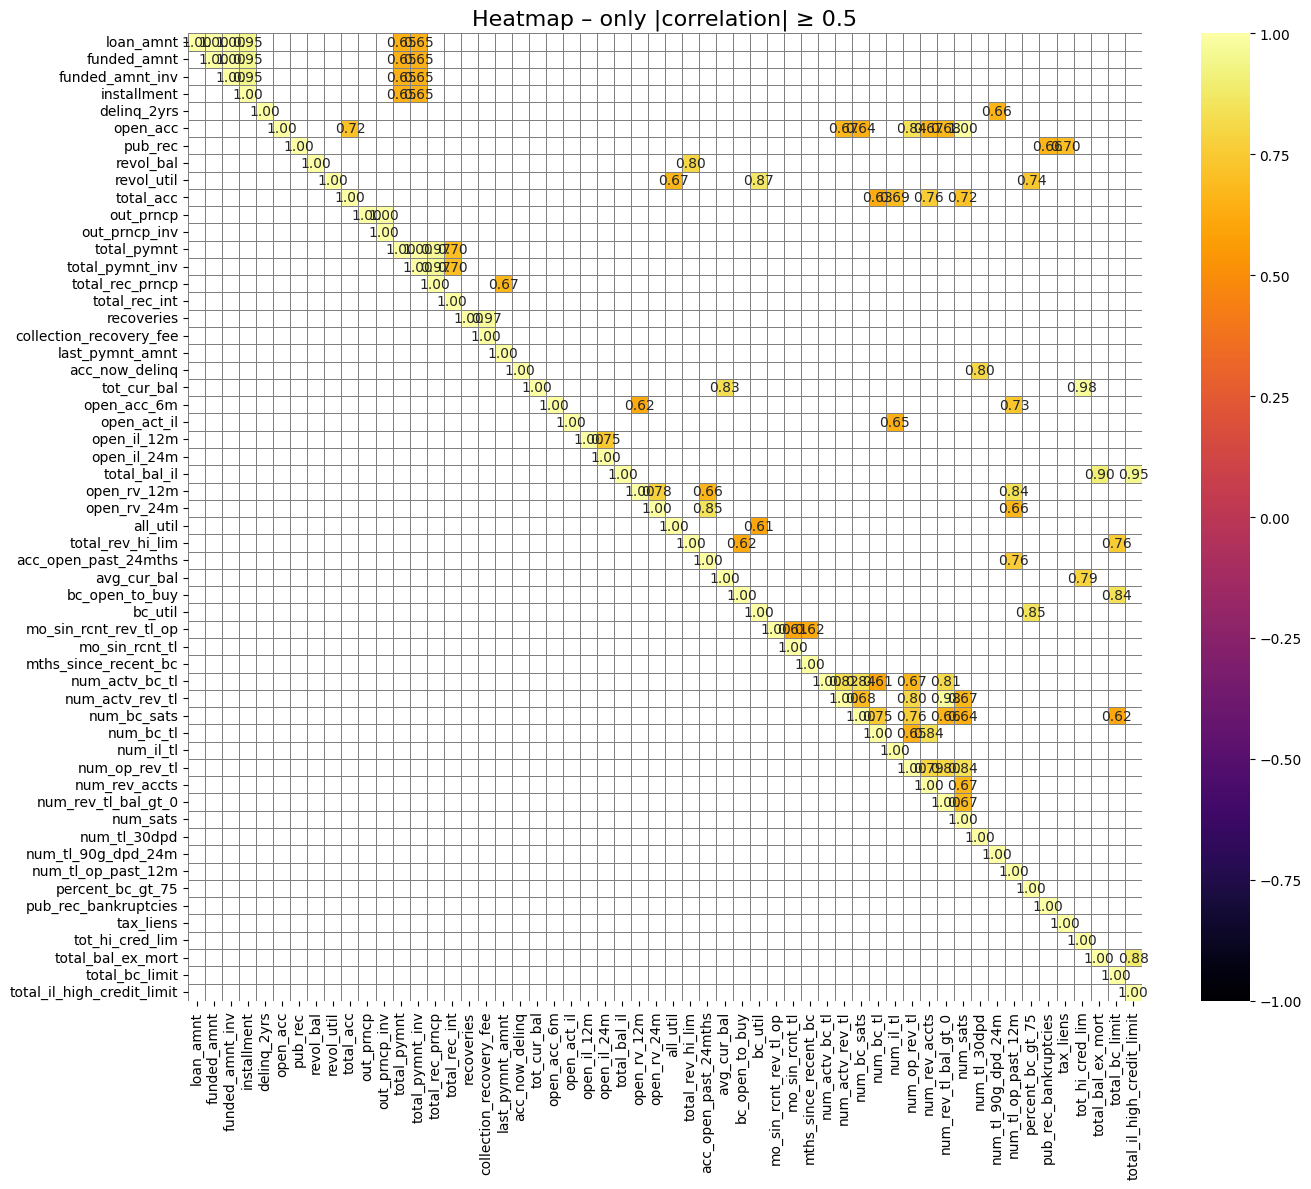

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) numeric columns only
df_num = df_loan.select_dtypes(include=[np.number])

# 2) full correlation matrix
corr = df_num.corr()

# 3) threshold
threshold = 0.6

# ---- A) choose only variables that have at least one strong correlation (excluding self) ----
corr_no_diag = corr.copy()
np.fill_diagonal(corr_no_diag.values, 0)      # ignore the 1.0 on the diagonal

cols_to_keep = corr_no_diag.columns[(corr_no_diag.abs() >= threshold).any(axis=1)]

# reduced correlation matrix
corr_strong = corr.loc[cols_to_keep, cols_to_keep]

display(corr_strong)

# ---- B) build mask: hide lower triangle + hide |corr| < threshold ----
mask = np.zeros_like(corr_strong, dtype=bool)

# hide lower triangle
mask[np.tril_indices_from(mask, k=-1)] = True

# also hide weak correlations
mask |= corr_strong.abs() < threshold

# ---- C) plot ----
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_strong,
    mask=mask,
    annot=True,
    cmap="inferno",
    vmin=-1,
    vmax=1,
    fmt=".2f",
    linewidths=.5,
    linecolor="gray"
)
plt.title("Heatmap – only |correlation| ≥ 0.5", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:

# Stack into list of pairs
corr_pairs = (
    corr.where(np.triu(np.ones_like(corr), k=1).astype(bool))  # upper triangle only
        .stack()
        .reset_index()
)

corr_pairs.columns = ["Feature_1", "Feature_2", "Correlation"]

# Filter strong correlations
strong_corr = corr_pairs.loc[corr_pairs["Correlation"].abs() >= threshold]

display(strong_corr.sort_values("Correlation", ascending=False))

,Feature_1,Feature_2,Correlation
1065,out_prncp,out_prncp_inv,0.999999
0,loan_amnt,funded_amnt,0.999755
1190,total_pymnt,total_pymnt_inv,0.999394
78,funded_amnt,funded_amnt_inv,0.999341
1,loan_amnt,funded_amnt_inv,0.999038
790,open_acc,num_sats,0.998966
2896,num_actv_rev_tl,num_rev_tl_bal_gt_0,0.983638
1852,tot_cur_bal,tot_hi_cred_lim,0.975582
1485,recoveries,collection_recovery_fee,0.968978
1191,total_pymnt,total_rec_prncp,0.967017


In [ ]:
#Removing Multicolliear Features
# Step 2 — Build redundancy groups from strong_corr pairs
groups = []

for _, row in strong_corr.iterrows():
    f1, f2 = row["Feature_1"], row["Feature_2"]
    
    added = False
    for g in groups:
        if f1 in g or f2 in g:
            g.update([f1, f2])
            added = True
            break
    
    if not added:
        groups.append(set([f1, f2]))

print("🔍 Redundancy Groups (correlation ≥ 0.9):")
for i, g in enumerate(groups, 1):
    print(f"Group {i}: {sorted(g)}")

🔍 Redundancy Groups (correlation ≥ 0.9):
Group 1: ['funded_amnt', 'funded_amnt_inv', 'installment', 'last_pymnt_amnt', 'loan_amnt', 'total_pymnt', 'total_pymnt_inv', 'total_rec_int', 'total_rec_prncp']
Group 2: ['delinq_2yrs', 'num_tl_90g_dpd_24m']
Group 3: ['num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'open_acc', 'open_act_il', 'total_acc', 'total_bc_limit']
Group 4: ['pub_rec', 'pub_rec_bankruptcies', 'tax_liens']
Group 5: ['bc_open_to_buy', 'revol_bal', 'total_bc_limit', 'total_rev_hi_lim']
Group 6: ['all_util', 'bc_util', 'percent_bc_gt_75', 'revol_util']
Group 7: ['out_prncp', 'out_prncp_inv']
Group 8: ['collection_recovery_fee', 'recoveries']
Group 9: ['acc_now_delinq', 'num_tl_30dpd']
Group 10: ['avg_cur_bal', 'tot_cur_bal', 'tot_hi_cred_lim']
Group 11: ['acc_open_past_24mths', 'num_tl_op_past_12m', 'open_acc_6m', 'open_rv_12m', 'open_rv_24m']
Group 12: ['open_il_12m', 'open_il_

In [ ]:
cols_to_drop = []

for g in groups:
    g = sorted(list(g))         # sort to make deterministic
    keep = g[0]                 # keep first one
    drop = g[1:]                # drop rest
    cols_to_drop.extend(drop)
    print(f"Keeping: {keep} | Dropping: {drop}")


Keeping: funded_amnt | Dropping: ['funded_amnt_inv', 'installment', 'last_pymnt_amnt', 'loan_amnt', 'total_pymnt', 'total_pymnt_inv', 'total_rec_int', 'total_rec_prncp']
Keeping: delinq_2yrs | Dropping: ['num_tl_90g_dpd_24m']
Keeping: num_actv_bc_tl | Dropping: ['num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'open_acc', 'open_act_il', 'total_acc', 'total_bc_limit']
Keeping: pub_rec | Dropping: ['pub_rec_bankruptcies', 'tax_liens']
Keeping: bc_open_to_buy | Dropping: ['revol_bal', 'total_bc_limit', 'total_rev_hi_lim']
Keeping: all_util | Dropping: ['bc_util', 'percent_bc_gt_75', 'revol_util']
Keeping: out_prncp | Dropping: ['out_prncp_inv']
Keeping: collection_recovery_fee | Dropping: ['recoveries']
Keeping: acc_now_delinq | Dropping: ['num_tl_30dpd']
Keeping: avg_cur_bal | Dropping: ['tot_cur_bal', 'tot_hi_cred_lim']
Keeping: acc_open_past_24mths | Dropping: ['num_tl_op_past_12m', 'open_acc_6m', 'open_rv_

In [ ]:
df_reduced = df_loan.drop(columns=cols_to_drop)

print("Dropped columns:\n", cols_to_drop)
print("New shape:", df_reduced.shape)


Dropped columns:
 ['funded_amnt_inv', 'installment', 'last_pymnt_amnt', 'loan_amnt', 'total_pymnt', 'total_pymnt_inv', 'total_rec_int', 'total_rec_prncp', 'num_tl_90g_dpd_24m', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'open_acc', 'open_act_il', 'total_acc', 'total_bc_limit', 'pub_rec_bankruptcies', 'tax_liens', 'revol_bal', 'total_bc_limit', 'total_rev_hi_lim', 'bc_util', 'percent_bc_gt_75', 'revol_util', 'out_prncp_inv', 'recoveries', 'num_tl_30dpd', 'tot_cur_bal', 'tot_hi_cred_lim', 'num_tl_op_past_12m', 'open_acc_6m', 'open_rv_12m', 'open_rv_24m', 'open_il_24m', 'total_bal_il', 'total_il_high_credit_limit', 'mo_sin_rcnt_tl', 'mths_since_recent_bc']
New shape: (2260668, 61)


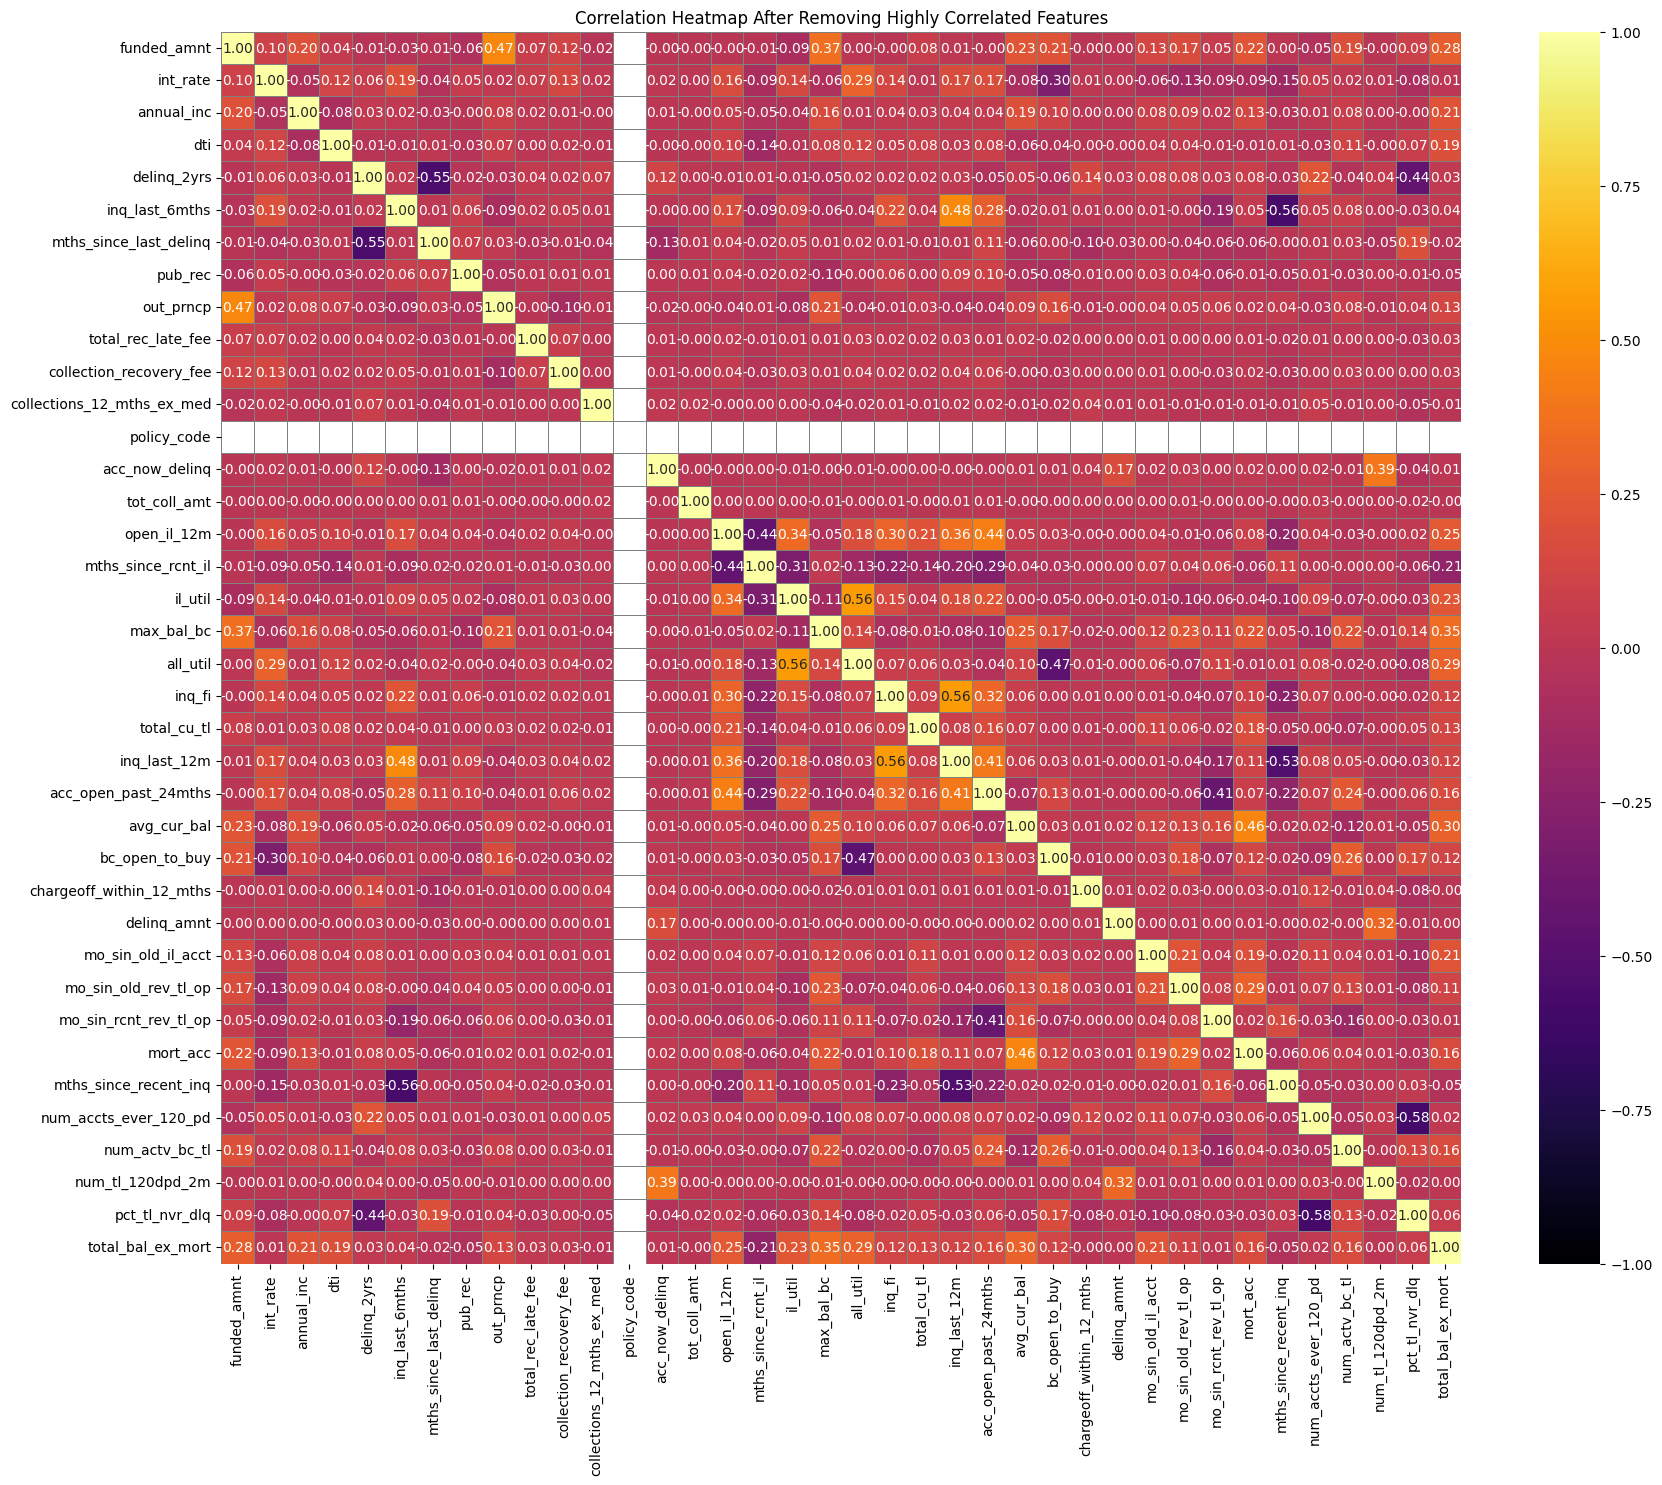

(2260668, 103)

42

(2260668, 61)

In [ ]:
df_num_reduced = df_reduced.select_dtypes(include=[np.number])
corr_clean = df_num_reduced.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_clean, 
            cmap="inferno", annot=True,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    linewidths=.5,
    linecolor="gray")
plt.title("Correlation Heatmap After Removing Highly Correlated Features")
plt.show()


display(df_loan.shape)
display(len(set(cols_to_drop)))
display(df_reduced.shape)



In [ ]:
df_loan.loc[
    df_loan["emp_title"] == 'Coil Winder "B", reactors',
    ["loan_amnt", "emp_title", "verification_status", "annual_inc", "home_ownership", "emp_length"]
]

,loan_amnt,emp_title,verification_status,annual_inc,home_ownership,emp_length
1046853,10500,"Coil Winder ""B"", reactors",Source Verified,38000.0,MORTGAGE,2 years


In [ ]:
# Display one row in vertical format
display(df_loan.head(5).T.style.set_properties(**{"text-align": "left"}))

,0,1,2,3,4
loan_amnt,2500,30000,5000,4000,30000
funded_amnt,2500,30000,5000,4000,30000
funded_amnt_inv,2500.000000,30000.000000,5000.000000,4000.000000,30000.000000
term,36 months,60 months,36 months,36 months,60 months
int_rate,13.560000,18.940000,17.970000,18.940000,16.140000
installment,84.920000,777.230000,180.690000,146.510000,731.780000
grade,C,D,D,D,C
sub_grade,C1,D2,D1,D2,C4
emp_title,Chef,Postmaster,Administrative,IT Supervisor,Mechanic
emp_length,10+ years,10+ years,6 years,10+ years,10+ years


In [ ]:
display(df_reduced.columns[df_reduced.isna().any()])

nan_report = pd.DataFrame({
    "NaN_Count": df_loan.isna().sum(),
    "NaN_Percent": (df_loan.isna().sum() / len(df_loan)) * 100
}).sort_values("NaN_Percent", ascending=False)

display(nan_report)

Index(['emp_title', 'emp_length', 'annual_inc', 'title', 'zip_code', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq', 'pub_rec', 'last_pymnt_d', 'next_pymnt_d', 'last_credit_pull_d', 'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_coll_amt', 'open_il_12m', 'mths_since_rcnt_il', 'il_util', 'max_bal_bc', 'all_util', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mort_acc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_tl_120dpd_2m', 'pct_tl_nvr_dlq', 'total_bal_ex_mort'], dtype='object')

,NaN_Count,NaN_Percent
next_pymnt_d,1303607,57.664681
mths_since_last_delinq,1158502,51.246003
il_util,1068850,47.280273
mths_since_rcnt_il,909924,40.250227
all_util,866348,38.322655
open_acc_6m,866130,38.313012
inq_last_12m,866130,38.313012
total_cu_tl,866130,38.313012
open_rv_24m,866129,38.312968
open_il_12m,866129,38.312968


In [ ]:

varx_sample = 1_500_000

# generate summary using sample
summary = resumetable(df_reduced.iloc[:varx_sample])

# sort by entropy FIRST
summary_sorted = summary.sort_values("Entropy", ascending=False)

# show top 60 columns with highest entropy
display(summary_sorted.iloc[:60])

# show the rest
display(summary_sorted.iloc[60:])


Dataset Shape: (1500000, 61)


,Name,dtypes,Missing,percentage missing,Uniques,First Value,Second Value,Third Value,Entropy
57,total_bal_ex_mort,float64,0,0.000000,194237,16901.0,99468.0,11749.0,16.87
44,avg_cur_bal,float64,42,0.002800,80920,1878.0,24763.0,18383.0,15.01
45,bc_open_to_buy,float64,16943,1.129533,84287,34360.0,13761.0,13800.0,14.70
5,emp_title,object,118052,7.870133,309249,Chef,Postmaster,Administrative,14.03
38,max_bal_bc,float64,399784,26.652267,32391,2137.0,998.0,0.0,13.70
17,dti,float64,1332,0.088800,10036,18.24,26.52,10.51,11.85
24,out_prncp,float64,0,0.000000,283287,2386.02,29387.75,4787.21,9.23
15,zip_code,object,1,0.000067,942,109xx,713xx,490xx,8.92
49,mo_sin_old_rev_tl_op,float64,0,0.000000,769,212.0,378.0,92.0,8.51
19,earliest_cr_line,object,0,0.000000,733,Apr-2001,Jun-1987,Apr-2011,8.46


,Name,dtypes,Missing,percentage missing,Uniques,First Value,Second Value,Third Value,Entropy
12,pymnt_plan,object,0,0.0,2,n,n,n,0.0


In [ ]:
def decide_action(row):
    # Use the REAL column names from summary
    m = row["percentage missing"]   # before: "missing_pct"
    dtype = row["dtypes"]           # before: "dtype"
    n_unique = row["Uniques"]       # before: "n_unique"
    
    # 1) ID-like or constant columns
    if n_unique <= 1:
        return "drop_constant"

    # 2) High-cardinality text
    if dtype == "object" and n_unique > 1000:
        return "high_card_text"

    # 3) Numeric with low missing
    # dtype here is a string like "float64", so wrap with np.dtype(...)
    if np.issubdtype(np.dtype(dtype), np.number) and m <= 5:
        return "impute_num_simple"  # mean/median

    # 4) Categorical with low missing
    if dtype == "object" and m <= 5:
        return "impute_cat_mode"   # most frequent

    # 5) Moderate missing 5–40%
    if 5 < m <= 40:
        return "impute_with_flag"

    # 6) Huge missing (>40%)
    if m > 40:
        return "consider_drop_or_flag"

    return "review_manual"
summary["action"] = summary.apply(decide_action, axis=1)
display(summary.sort_values("Entropy", ascending=False).head(60))


,Name,dtypes,Missing,percentage missing,Uniques,First Value,Second Value,Third Value,Entropy,action
57,total_bal_ex_mort,float64,0,0.000000,194237,16901.0,99468.0,11749.0,16.87,impute_num_simple
44,avg_cur_bal,float64,42,0.002800,80920,1878.0,24763.0,18383.0,15.01,impute_num_simple
45,bc_open_to_buy,float64,16943,1.129533,84287,34360.0,13761.0,13800.0,14.70,impute_num_simple
5,emp_title,object,118052,7.870133,309249,Chef,Postmaster,Administrative,14.03,high_card_text
38,max_bal_bc,float64,399784,26.652267,32391,2137.0,998.0,0.0,13.70,impute_with_flag
17,dti,float64,1332,0.088800,10036,18.24,26.52,10.51,11.85,impute_num_simple
24,out_prncp,float64,0,0.000000,283287,2386.02,29387.75,4787.21,9.23,impute_num_simple
15,zip_code,object,1,0.000067,942,109xx,713xx,490xx,8.92,impute_cat_mode
49,mo_sin_old_rev_tl_op,float64,0,0.000000,769,212.0,378.0,92.0,8.51,impute_num_simple
19,earliest_cr_line,object,0,0.000000,733,Apr-2001,Jun-1987,Apr-2011,8.46,impute_cat_mode


### 3. Data Transformation

**Continuous variables**



**Discrete variables**

I converted several categorical variables into numerical representation:

- `sub_grade` → `grade_level` (1–35)
- `emp_length` → `emp_length_num` (0.5, 1, 2, …, 10)
- One-hot encoding (`get_dummies`) for:
  - `term`
  - `home_ownership`
  - `verification_status`
  - `purpose`
  - `application_type`
  - `hardship_flag`
  - `debt_settlement_flag`
  - `addr_state`

This produces binary columns (0/1) indicating the presence of each category.

### 4. New Columns

I created several new columns during preprocessing:

- `grade_level`: numeric representation of `sub_grade` (A1–G5 → 1–35).
- `emp_length_num`: numeric years of employment (e.g., `< 1 year` → 0.5, `10+ years` → 10).
- Missingness indicators: columns such as `il_util_was_missing` show where the original value was missing.
- One-hot encoded dummy variables for categorical features (e.g., `term_ 60 months`, `home_ownership_RENT`, …).
- `bad_loan`: binary response variable for modeling, equal to 1 for bad outcomes (e.g., *Charged Off*, *Default*) and 0 otherwise.

These additional columns are stored in the final dataset and used later for model training and interpretation.


In [ ]:
# Categorical columns with low missing that we want to one-hot encoding
ohe_cols = summary.loc[
    (summary["action"] == "impute_cat_mode") & 
    (summary["dtypes"] == "object"),
    "Name"
].tolist()

# Remove ordered variables that we encode as numeric
ohe_cols = [c for c in ohe_cols if c not in ["grade", "sub_grade"]]

display(ohe_cols)


['term',
 'home_ownership',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'earliest_cr_line',
 'initial_list_status',
 'last_pymnt_d',
 'last_credit_pull_d',
 'application_type',
 'hardship_flag',
 'disbursement_method',
 'debt_settlement_flag']

In [ ]:
grade_map = {
 'A1':1,'A2':2,'A3':3,'A4':4,'A5':5,
 'B1':6,'B2':7,'B3':8,'B4':9,'B5':10,
 'C1':11,'C2':12,'C3':13,'C4':14,'C5':15,
 'D1':16,'D2':17,'D3':18,'D4':19,'D5':20,
 'E1':21,'E2':22,'E3':23,'E4':24,'E5':25,
 'F1':26,'F2':27,'F3':28,'F4':29,'F5':30,
 'G1':31,'G2':32,'G3':33,'G4':34,'G5':35,
}
display(df_reduced.columns)


Index(['funded_amnt', 'term', 'int_rate', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq', 'pub_rec', 'initial_list_status', 'out_prncp', 'total_rec_late_fee', 'collection_recovery_fee', 'last_pymnt_d', 'next_pymnt_d', 'last_credit_pull_d', 'collections_12_mths_ex_med', 'policy_code', 'application_type', 'acc_now_delinq', 'tot_coll_amt', 'open_il_12m', 'mths_since_rcnt_il', 'il_util', 'max_bal_bc', 'all_util', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mort_acc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_tl_120dpd_2m', 'pct_tl_nvr_dlq', 'total_bal_ex_mort', 'hardshi

In [ ]:
df_reduced["grade_level"] = df_reduced["sub_grade"].map(grade_map)
df_reduced = df_reduced.drop(columns=["grade", "sub_grade"])

display(df_reduced.columns)

Index(['funded_amnt', 'term', 'int_rate', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq', 'pub_rec', 'initial_list_status', 'out_prncp', 'total_rec_late_fee', 'collection_recovery_fee', 'last_pymnt_d', 'next_pymnt_d', 'last_credit_pull_d', 'collections_12_mths_ex_med', 'policy_code', 'application_type', 'acc_now_delinq', 'tot_coll_amt', 'open_il_12m', 'mths_since_rcnt_il', 'il_util', 'max_bal_bc', 'all_util', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mort_acc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_tl_120dpd_2m', 'pct_tl_nvr_dlq', 'total_bal_ex_mort', 'hardship_flag', 'disbursement

In [ ]:
#new numerical emp_length feature
df_reduced['emp_length'].value_counts()


emp_length
10+ years    748005
2 years      203677
< 1 year     189988
3 years      180753
1 year       148403
5 years      139698
4 years      136605
6 years      102628
7 years       92695
8 years       91914
9 years       79395
Name: count, dtype: int64

In [ ]:
import numpy as np
import pandas as pd

def EmpLength(x):
    # 1) Missing values -> keep as NaN (or choose a value you like)
    if pd.isna(x):
        return np.nan          # or e.g. 0.5

    x = str(x).strip()         # make sure it's a string

    # 2) Special cases
    if x == '< 1 year':
        return 0.5
    elif x.lower() == 'n/a':
        # assuming not filled means < 1 year
        return 0.5
    elif x == '10+ years':
        return 10

    # 3) Normal cases like '2 years', '1 year'
    # take the first token ('2', '1', etc.)
    try:
        return float(x.split()[0])
    except Exception:
        # fallback if some weird value appears
        return np.nan

# Apply the transformation
df_reduced['emp_length_num'] = df_reduced['emp_length'].map(EmpLength)

# (optional) drop original column
df_reduced = df_reduced.drop(columns=['emp_length'])

# Check result
df_reduced['emp_length_num'].value_counts(dropna=False)


emp_length_num
10.0    748005
2.0     203677
0.5     189988
3.0     180753
1.0     148403
NaN     146907
5.0     139698
4.0     136605
6.0     102628
7.0      92695
8.0      91914
9.0      79395
Name: count, dtype: int64

In [ ]:
df_reduced['issue_d'].value_counts(dropna=False)

issue_d
Mar-2016    61992
Oct-2015    48631
May-2018    46311
Oct-2018    46305
Aug-2018    46079
Jul-2015    45962
Dec-2015    44343
Aug-2017    43573
Jul-2018    43089
Apr-2018    42928
Nov-2017    42343
Nov-2018    41973
Jun-2018    41533
Dec-2018    40134
Sep-2017    39713
Feb-2016    39529
Jul-2017    39415
Sep-2018    39026
Oct-2014    38783
Mar-2018    38771
Dec-2017    38154
Oct-2017    38151
Jun-2017    38087
May-2017    37681
Nov-2015    37530
Mar-2017    37181
Apr-2016    36432
Jan-2018    36347
Aug-2016    36280
Dec-2016    36183
Aug-2015    35886
Apr-2015    35427
Jan-2015    35107
Jul-2016    34696
Nov-2016    34591
Jun-2016    33019
Oct-2016    32772
Feb-2018    32746
Jan-2016    32366
May-2015    31913
Jan-2017    31835
Apr-2017    29683
Jul-2014    29306
Sep-2015    28641
Jun-2015    28485
May-2016    28403
Sep-2016    28144
Feb-2017    27763
Mar-2015    25400
Nov-2014    25054
Feb-2015    23770
May-2014    19099
Apr-2014    19071
Aug-2014    18814
Jun-2014    17179
Ma

In [ ]:
df_reduced['issue_d'] = pd.to_datetime(df_reduced.issue_d)
display(df_reduced['issue_d'].value_counts(dropna=False))
display(df_reduced['issue_d'].dtype)

C:\Users\k.key B\AppData\Local\Temp\ipykernel_14684\1303735812.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_reduced['issue_d'] = pd.to_datetime(df_reduced.issue_d)


issue_d
2016-03-01    61992
2015-10-01    48631
2018-05-01    46311
2018-10-01    46305
2018-08-01    46079
2015-07-01    45962
2015-12-01    44343
2017-08-01    43573
2018-07-01    43089
2018-04-01    42928
2017-11-01    42343
2018-11-01    41973
2018-06-01    41533
2018-12-01    40134
2017-09-01    39713
2016-02-01    39529
2017-07-01    39415
2018-09-01    39026
2014-10-01    38783
2018-03-01    38771
2017-12-01    38154
2017-10-01    38151
2017-06-01    38087
2017-05-01    37681
2015-11-01    37530
2017-03-01    37181
2016-04-01    36432
2018-01-01    36347
2016-08-01    36280
2016-12-01    36183
2015-08-01    35886
2015-04-01    35427
2015-01-01    35107
2016-07-01    34696
2016-11-01    34591
2016-06-01    33019
2016-10-01    32772
2018-02-01    32746
2016-01-01    32366
2015-05-01    31913
2017-01-01    31835
2017-04-01    29683
2014-07-01    29306
2015-09-01    28641
2015-06-01    28485
2016-05-01    28403
2016-09-01    28144
2017-02-01    27763
2015-03-01    25400
2014-11-01  

dtype('<M8[ns]')

In [ ]:
def to_year_month(s):
    if pd.isna(s): return np.nan
    return pd.to_datetime(s, format="%b-%Y").to_period("M").to_timestamp()

df_loan["issue_year"]  = pd.to_datetime(df_loan["issue_d"]).dt.year
df_loan["issue_month"] = pd.to_datetime(df_loan["issue_d"]).dt.month
df_loan["last_pymnt_year"]  = pd.to_datetime(df_loan["last_pymnt_d"]).dt.year
df_loan["last_pymnt_month"] = pd.to_datetime(df_loan["last_pymnt_d"]).dt.month
df_loan["last_credit_pull_year"]  = pd.to_datetime(df_loan["last_credit_pull_d"]).dt.year

df_loan.drop(columns=["issue_d","last_pymnt_d","last_credit_pull_d"], inplace=True)

C:\Users\k.key B\AppData\Local\Temp\ipykernel_14684\4110705370.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_loan["issue_year"]  = pd.to_datetime(df_loan["issue_d"]).dt.year
C:\Users\k.key B\AppData\Local\Temp\ipykernel_14684\4110705370.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_loan["issue_month"] = pd.to_datetime(df_loan["issue_d"]).dt.month
C:\Users\k.key B\AppData\Local\Temp\ipykernel_14684\4110705370.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_loan["last_pymnt_year"]  = pd.to_datetime(df_loan["last_pymnt_d"]).dt.year
C:\Users\k.key B\App

In [ ]:
# columns that we decided are "categorical with low missing"
display(summary.loc[summary["action"] == "impute_cat_mode",])

cat_low_miss = summary.loc[summary["action"] == "impute_cat_mode", "Name"].tolist()
display(cat_low_miss)

# 2) Remove the high-cardinality ones you don't want to OHE
cols_to_exclude = ["zip_code", "earliest_cr_line","grade","sub_grade","last_pymnt_d","last_credit_pull_d","issue_d"]   # add 'title' if you want
cat_low_miss = [c for c in cat_low_miss if c not in cols_to_exclude]

display(cat_low_miss)

,Name,dtypes,Missing,percentage missing,Uniques,First Value,Second Value,Third Value,Entropy,action
1,term,object,0,0.000000,2,36 months,60 months,36 months,0.87,impute_cat_mode
3,grade,object,0,0.000000,7,C,D,D,2.27,impute_cat_mode
4,sub_grade,object,0,0.000000,35,C1,D2,D1,4.58,impute_cat_mode
7,home_ownership,object,0,0.000000,5,RENT,MORTGAGE,MORTGAGE,1.40,impute_cat_mode
9,verification_status,object,0,0.000000,3,Not Verified,Source Verified,Source Verified,1.56,impute_cat_mode
10,issue_d,object,0,0.000000,41,Dec-2018,Dec-2018,Dec-2018,5.32,impute_cat_mode
11,loan_status,object,0,0.000000,7,Current,Current,Current,1.51,impute_cat_mode
12,pymnt_plan,object,0,0.000000,2,n,n,n,0.00,impute_cat_mode
13,purpose,object,0,0.000000,14,debt_consolidation,debt_consolidation,debt_consolidation,1.95,impute_cat_mode
14,title,object,23305,1.553667,28,Debt consolidation,Debt consolidation,Debt consolidation,1.95,impute_cat_mode


['term',
 'grade',
 'sub_grade',
 'home_ownership',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'earliest_cr_line',
 'initial_list_status',
 'last_pymnt_d',
 'last_credit_pull_d',
 'application_type',
 'hardship_flag',
 'disbursement_method',
 'debt_settlement_flag']

['term',
 'home_ownership',
 'verification_status',
 'loan_status',
 'pymnt_plan',
 'purpose',
 'title',
 'addr_state',
 'initial_list_status',
 'application_type',
 'hardship_flag',
 'disbursement_method',
 'debt_settlement_flag']

In [ ]:
small_cat_cols = [
    "term",             # or use grade_level numeric instead of sub_grade
    "home_ownership",
    "verification_status",
    "purpose",
    "application_type",
    "hardship_flag",
    "debt_settlement_flag",
    "addr_state",
]

# 1) fillna with mode
for c in small_cat_cols:
    df_reduced[c] = df_reduced[c].fillna(df_reduced[c].mode()[0])

# 2) only OHE these few
df_encoded = pd.get_dummies(df_reduced, columns=small_cat_cols, drop_first=True)
df_encoded.shape

(2260668, 126)

In [ ]:
from IPython.display import HTML
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 2000)


summary = resumetable(df_encoded)
display(summary.head(130))

Dataset Shape: (2260668, 126)


,Name,dtypes,Missing,percentage missing,Uniques,First Value,Second Value,Third Value,Entropy
0,funded_amnt,int64,0,0.000000,1572,2500,30000,5000,6.73
1,int_rate,float64,0,0.000000,673,13.56,18.94,17.97,7.73
2,emp_title,object,166969,7.385826,512694,Chef,Postmaster,Administrative,14.70
3,annual_inc,float64,4,0.000177,89368,55000.0,90000.0,59280.0,8.33
4,issue_d,datetime64[ns],0,0.000000,139,2018-12-01 00:00:00,2018-12-01 00:00:00,2018-12-01 00:00:00,6.25
5,loan_status,object,0,0.000000,9,Current,Current,Current,1.53
6,pymnt_plan,object,0,0.000000,2,n,n,n,0.00
7,title,object,23326,1.031819,63154,Debt consolidation,Debt consolidation,Debt consolidation,3.25
8,zip_code,object,1,0.000044,956,109xx,713xx,490xx,8.91
9,dti,float64,1711,0.075686,10845,18.24,26.52,10.51,11.81


In [ ]:
summary["action"] = summary.apply(decide_action, axis=1)
display(summary.sort_values("Entropy", ascending=False).head(300))

,Name,dtypes,Missing,percentage missing,Uniques,First Value,Second Value,Third Value,Entropy,action
48,total_bal_ex_mort,float64,50030,2.213063,212777,16901.0,99468.0,11749.0,16.87,impute_num_simple
35,avg_cur_bal,float64,70346,3.111735,88597,1878.0,24763.0,18383.0,15.03,impute_num_simple
2,emp_title,object,166969,7.385826,512694,Chef,Postmaster,Administrative,14.70,high_card_text
36,bc_open_to_buy,float64,74935,3.314728,91500,34360.0,13761.0,13800.0,14.63,impute_num_simple
29,max_bal_bc,float64,866129,38.312968,33726,2137.0,998.0,0.0,13.69,impute_with_flag
9,dti,float64,1711,0.075686,10845,18.24,26.52,10.51,11.81,impute_num_simple
8,zip_code,object,1,0.000044,956,109xx,713xx,490xx,8.91,impute_cat_mode
40,mo_sin_old_rev_tl_op,float64,70277,3.108683,787,212.0,378.0,92.0,8.50,impute_num_simple
11,earliest_cr_line,object,29,0.001283,754,Apr-2001,Jun-1987,Apr-2011,8.47,impute_cat_mode
3,annual_inc,float64,4,0.000177,89368,55000.0,90000.0,59280.0,8.33,impute_num_simple


In [ ]:
# Drop columns we don’t want in the model
# cols_to_drop = [
#     "emp_title",        # high-card text
#     "title",            # high-card text
#     "zip_code",         # many categories
#     "earliest_cr_line", # redundant info
#     "policy_code",      # constant 1
# ]

# df_encoded = df_encoded.drop(columns=cols_to_drop, errors="ignore")

# Convert bool -> int (Spark is happier with numeric types)
bool_cols = df_encoded.select_dtypes(bool).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype("int8")


3.	Data Transformation

In [ ]:
#numerical features - means 
print(df_encoded.select_dtypes(include=['float64']).apply(np.mean).apply(str))


int_rate                          13.09291294431558
annual_inc                        77992.42868706721
dti                               18.82419643667409
delinq_2yrs                      0.3068791611575311
inq_last_6mths                   0.5768353889477218
mths_since_last_delinq           34.540915796713016
pub_rec                          0.1975277786501958
out_prncp                         4446.292883470726
total_rec_late_fee               1.4624688877333347
collection_recovery_fee          22.593283703570865
collections_12_mths_ex_med     0.018145800772653053
acc_now_delinq                 0.004147942241109704
tot_coll_amt                     232.73173888509453
open_il_12m                      0.6764314228573026
mths_since_rcnt_il                21.22235671600244
il_util                           69.14097957909681
max_bal_bc                        5806.392904752036
all_util                          57.03229531241035
inq_fi                           1.0128666175703942
total_cu_tl 

In [ ]:
cols_to_drop = [
    "emp_title",        # high-card text
    "title",            # high-card text
    # "zip_code",         # many categories
    "earliest_cr_line", # redundant info
    "policy_code",      # constant 1
]

df_encoded = df_encoded.drop(columns=cols_to_drop, errors="ignore")

summary = resumetable(df_encoded)
display(summary.head(130))

Dataset Shape: (2260668, 122)


,Name,dtypes,Missing,percentage missing,Uniques,First Value,Second Value,Third Value,Entropy
0,funded_amnt,int64,0,0.000000,1572,2500,30000,5000,6.73
1,int_rate,float64,0,0.000000,673,13.56,18.94,17.97,7.73
2,annual_inc,float64,4,0.000177,89368,55000.0,90000.0,59280.0,8.33
3,issue_d,datetime64[ns],0,0.000000,139,2018-12-01 00:00:00,2018-12-01 00:00:00,2018-12-01 00:00:00,6.25
4,loan_status,object,0,0.000000,9,Current,Current,Current,1.53
5,pymnt_plan,object,0,0.000000,2,n,n,n,0.00
6,zip_code,object,1,0.000044,956,109xx,713xx,490xx,8.91
7,dti,float64,1711,0.075686,10845,18.24,26.52,10.51,11.81
8,delinq_2yrs,float64,29,0.001283,37,0.0,0.0,0.0,0.98
9,inq_last_6mths,float64,30,0.001327,28,1.0,0.0,0.0,1.49


In [ ]:
import pandas as pd
from IPython.display import display

# Parameters
MAX_VALUES = 100      # global cap: max number of unique values shown per column
CHUNK_SIZE = 13       # max number of columns per display

# 1) Use summary ONLY to select low-cardinality columns
cols_low_card = summary.loc[summary["Uniques"] < 100, ["Name", "Uniques"]].copy()

# 2) Recompute uniques *from df_loan* to avoid mismatch
cols_low_card["True_Uniques"] = cols_low_card["Name"].apply(
    lambda c: df_encoded[c].nunique(dropna=True)
)

# 3) Sort by the true unique count (DESC)
cols_low_card = cols_low_card.sort_values("True_Uniques", ascending=False)

# Show reference table (summary uniques vs true uniques)
display(cols_low_card)

col_names_ordered = cols_low_card["Name"].tolist()

# 4) Build blocks of up to CHUNK_SIZE columns each
for start in range(0, len(col_names_ordered), CHUNK_SIZE):
    chunk_cols = col_names_ordered[start:start + CHUNK_SIZE]

    # First pass: compute uniques per column and store
    chunk_info = {}

    for col in chunk_cols:
        # All uniques (drop NaN)
        uniques = df_encoded[col].dropna().unique()

        # Sort values if possible
        try:
            uniques = sorted(uniques)
        except TypeError:
            pass

        # True unique count from df_loan
        unique_count = df_encoded[col].nunique(dropna=True)

        # Limit displayed uniques globally to MAX_VALUES
        uniques_display = uniques[:MAX_VALUES]

        chunk_info[col] = {
            "unique_count": unique_count,
            "uniques_display": uniques_display,
        }

    # Max number of values we will display in THIS chunk
    chunk_max_values = max(len(info["uniques_display"]) for info in chunk_info.values())

    # 5) Build matrix for this chunk
    data = {}
    for col in chunk_cols:
        unique_count = chunk_info[col]["unique_count"]
        uniques_display = list(chunk_info[col]["uniques_display"])

        # First row = unique count
        col_values = [unique_count] + uniques_display

        # Pad to 1 + chunk_max_values
        needed_len = 1 + chunk_max_values
        if len(col_values) < needed_len:
            col_values.extend([pd.NA] * (needed_len - len(col_values)))

        data[col] = col_values

    # Index labels adapt to this chunk
    index_labels = ["Unique_Count"] + [
        f"value_{i}" for i in range(1, chunk_max_values + 1)
    ]
    df_block = pd.DataFrame(data, index=index_labels)

    # 6) Show the chunk
    display(
        df_block.style.set_caption(
            f"Columns {start+1}–{start+len(chunk_cols)} "
            f"(sorted by True_Uniques DESC, max {chunk_max_values} values in this chunk)"
        )
    )


,Name,Uniques,True_Uniques
28,total_cu_tl,62,62
30,acc_open_past_24mths,57,57
29,inq_last_12m,48,48
38,mort_acc,47,47
40,num_accts_ever_120_pd,44,44
11,pub_rec,43,43
41,num_actv_bc_tl,42,42
8,delinq_2yrs,37,37
46,grade_level,35,35
27,inq_fi,33,33


,total_cu_tl,acc_open_past_24mths,inq_last_12m,mort_acc,num_accts_ever_120_pd,pub_rec,num_actv_bc_tl,delinq_2yrs,grade_level,inq_fi,inq_last_6mths,mths_since_recent_inq,open_il_12m
Unique_Count,62.000000,57,48,47,44,43,42,37,35,33,28,26,19
value_1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1,0.000000,0.000000,0.000000,0.000000
value_2,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2,1.000000,1.000000,1.000000,1.000000
value_3,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3,2.000000,2.000000,2.000000,2.000000
value_4,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4,3.000000,3.000000,3.000000,3.000000
value_5,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5,4.000000,4.000000,4.000000,4.000000
value_6,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,6,5.000000,5.000000,5.000000,5.000000
value_7,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,7,6.000000,6.000000,6.000000,6.000000
value_8,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,8,7.000000,7.000000,7.000000,7.000000
value_9,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,9,8.000000,8.000000,8.000000,8.000000


,collections_12_mths_ex_med,chargeoff_within_12_mths,emp_length_num,acc_now_delinq,loan_status,num_tl_120dpd_2m,addr_state_IN,addr_state_NJ,addr_state_NE,addr_state_ND,addr_state_NC,addr_state_MT,addr_state_MS
Unique_Count,16.000000,11,11,9,9,7,2,2,2,2,2,2,2
value_1,0.000000,0.000000,0.500000,0.000000,Charged Off,0.000000,0,0,0,0,0,0,0
value_2,1.000000,1.000000,1.000000,1.000000,Current,1.000000,1,1,1,1,1,1,1
value_3,2.000000,2.000000,2.000000,2.000000,Default,2.000000,,,,,,,
value_4,3.000000,3.000000,3.000000,3.000000,Does not meet the credit policy. Status:Charged Off,3.000000,,,,,,,
value_5,4.000000,4.000000,4.000000,4.000000,Does not meet the credit policy. Status:Fully Paid,4.000000,,,,,,,
value_6,5.000000,5.000000,5.000000,5.000000,Fully Paid,6.000000,,,,,,,
value_7,6.000000,6.000000,6.000000,6.000000,In Grace Period,7.000000,,,,,,,
value_8,7.000000,7.000000,7.000000,7.000000,Late (16-30 days),,,,,,,,
value_9,8.000000,8.000000,8.000000,14.000000,Late (31-120 days),,,,,,,,


,addr_state_MO,addr_state_MN,addr_state_MI,addr_state_ME,addr_state_MD,addr_state_MA,addr_state_LA,addr_state_KY,addr_state_KS,addr_state_IL,addr_state_NH,addr_state_SD,addr_state_NM
Unique_Count,2,2,2,2,2,2,2,2,2,2,2,2,2
value_1,0,0,0,0,0,0,0,0,0,0,0,0,0
value_2,1,1,1,1,1,1,1,1,1,1,1,1,1


,addr_state_TN,addr_state_WV,addr_state_WI,addr_state_WA,addr_state_VT,addr_state_VA,addr_state_UT,addr_state_TX,addr_state_IA,addr_state_NV,addr_state_SC,addr_state_RI,addr_state_PA
Unique_Count,2,2,2,2,2,2,2,2,2,2,2,2,2
value_1,0,0,0,0,0,0,0,0,0,0,0,0,0
value_2,1,1,1,1,1,1,1,1,1,1,1,1,1


,addr_state_OR,addr_state_OK,addr_state_OH,addr_state_NY,addr_state_ID,addr_state_AZ,addr_state_HI,verification_status_Source Verified,purpose_major_purchase,purpose_house,purpose_home_improvement,purpose_educational,purpose_debt_consolidation
Unique_Count,2,2,2,2,2,2,2,2,2,2,2,2,2
value_1,0,0,0,0,0,0,0,0,0,0,0,0,0
value_2,1,1,1,1,1,1,1,1,1,1,1,1,1


,purpose_credit_card,verification_status_Verified,home_ownership_RENT,addr_state_GA,home_ownership_OWN,home_ownership_OTHER,home_ownership_NONE,home_ownership_MORTGAGE,term_ 60 months,disbursement_method,initial_list_status,purpose_medical,purpose_moving
Unique_Count,2,2,2,2,2,2,2,2,2,2,2,2,2
value_1,0,0,0,0,0,0,0,0,0,Cash,f,0,0
value_2,1,1,1,1,1,1,1,1,1,DirectPay,w,1,1


,purpose_other,purpose_renewable_energy,addr_state_FL,addr_state_DE,addr_state_DC,addr_state_CT,addr_state_CO,addr_state_CA,pymnt_plan,addr_state_AR,addr_state_AL,debt_settlement_flag_Y,hardship_flag_Y
Unique_Count,2,2,2,2,2,2,2,2,2,2,2,2,2
value_1,0,0,0,0,0,0,0,0,n,0,0,0,0
value_2,1,1,1,1,1,1,1,1,y,1,1,1,1


,application_type_Joint App,purpose_wedding,purpose_vacation,purpose_small_business,addr_state_WY
Unique_Count,2,2,2,2,2
value_1,0,0,0,0,0
value_2,1,1,1,1,1


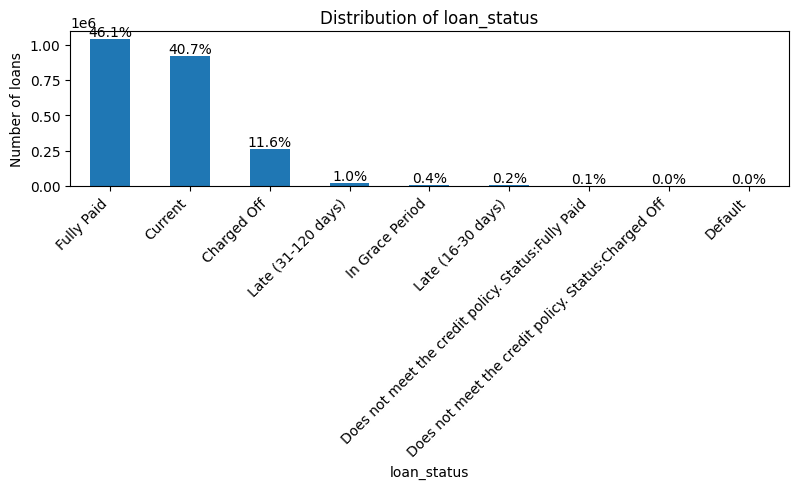

In [ ]:
#distribution of our class/targer variable Late_Loan , True if loan is late. 
import matplotlib.pyplot as plt

# counts and percentages
counts = df_encoded['loan_status'].value_counts()
pct    = df_encoded['loan_status'].value_counts(normalize=True) * 100

plt.figure(figsize=(8,5))
ax = counts.plot(kind='bar')

plt.ylabel("Number of loans")
plt.title("Distribution of loan_status")
plt.xticks(rotation=45, ha='right')

# add percentage labels on top of each bar
for i, p in enumerate(ax.patches):
    ax.annotate(f"{pct.iloc[i]:.1f}%",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

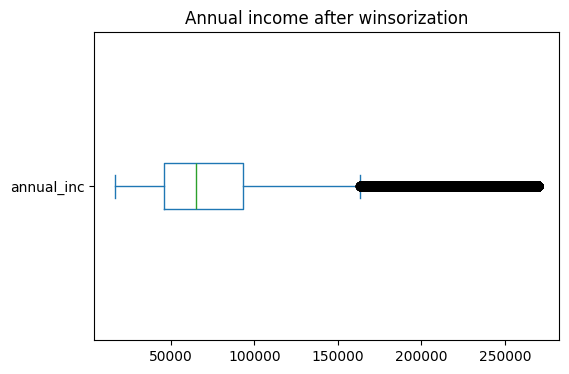

In [ ]:
# Basic describe
df_encoded[["int_rate", "annual_inc", "dti"]].describe()

# Example: remove impossible negatives
for c in ["int_rate", "annual_inc", "dti"]:
    df_encoded.loc[df_encoded[c] < 0, c] = np.nan

# Winsorization function (cap at 1st and 99th percentile)
def winsorize_series(s, lower=0.01, upper=0.99):
    lo = s.quantile(lower)
    hi = s.quantile(upper)
    return s.clip(lower=lo, upper=hi)

df_encoded["annual_inc"] = winsorize_series(df_encoded["annual_inc"])
df_encoded["dti"]        = winsorize_series(df_encoded["dti"])

# Optional: visualize one variable
plt.figure(figsize=(6,4))
df_encoded["annual_inc"].plot(kind="box", vert=False)
plt.title("Annual income after winsorization")
plt.show()


### 5. Scaling to a Much Larger Dataset

If the dataset were 10,000 times larger, it would not fit comfortably in a single machine’s memory.  
In that case I would:

- store the data in a **distributed format** (e.g., Parquet files in HDFS / cloud storage),
- use **Apache Spark** (PySpark) to:
  - read the data as a Spark DataFrame,
  - apply the same preprocessing steps using Spark’s `VectorAssembler`, `StringIndexer`, `OneHotEncoder`, and `StandardScaler`,
  - train scalable models (e.g., Spark MLlib logistic regression or tree-based models),
- possibly back the data with a distributed database / data warehouse (e.g., Delta Lake, BigQuery, Snowflake) depending on the environment.

Spark is designed exactly for this type of big tabular dataset and allows me to keep the same logic but run it in a distributed way across a cluster.
